# Intrusion Detection using Machine Learning on ALLFLOWMETER_HIKARI2021

## Objective
The objective of this notebook is to build, validate and evaluate supervised Machine Learning models capable of detecting malicious network traffic using the **ALLFLOWMETER_HIKARI2021** dataset.

The target variable is `Label`, where the expected interpretation is:

- `0` = benign traffic
- `1` = malicious / attack traffic

This work follows the AI for Cybersecurity workflow: dataset understanding, preprocessing, model training, evaluation, and cybersecurity interpretation.


> **Execution note:** this revised notebook changes the validation workflow. Restart the kernel and run all cells from top to bottom so that every result is regenerated consistently.

## Research question

**Can supervised Machine Learning models accurately distinguish benign network flows from malicious network flows using flow-based features from the ALLFLOWMETER_HIKARI2021 dataset?**

From a cybersecurity perspective, the most critical operational requirement is not only high global accuracy, but also strong **attack recall**, because false negatives represent attacks that the IDS fails to detect.


## Dataset description

The ALLFLOWMETER_HIKARI2021 dataset contains network-flow features extracted from traffic captures. Each row represents a network flow and includes statistical traffic features such as packet counts, byte counts, duration, inter-arrival timing, and protocol behaviour.

This dataset is relevant for cybersecurity because it supports the development of **Intrusion Detection Systems (IDS)**. In this context, Machine Learning models learn patterns that differentiate benign activity from suspicious or malicious traffic.

The notebook assumes that the dataset file is available in one of the following locations:

- `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`


## 1. Environment setup and imports

This step prepares the Python environment used for the full Machine Learning pipeline.

**Why this matters:** a notebook is only useful if another person can rerun it. Importing all libraries at the beginning makes the dependencies visible and supports reproducibility.

**What is imported:**

- `pandas` and `numpy` for tabular data processing.
- `matplotlib` for charts.
- `pathlib` for robust file-path handling.
- `scikit-learn` modules for train/test split, scaling, model training, metrics and visual evaluation.

The `RANDOM_STATE` variable fixes the pseudo-random operations. This does not make the model universally deterministic in every platform, but it strongly improves reproducibility for splits and model initialization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
MINIMUM_ATTACK_RECALL = 0.98

pd.set_option("display.max_columns", 120)


## 2. Load dataset

This step loads the CSV file into a pandas DataFrame.

**Why this matters:** the dataset is the input asset of the IDS experiment. If the file path is hard-coded for only one computer, the notebook becomes fragile. Therefore, the code checks multiple likely paths:

1. `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`
2. `data/raw/ALLFLOWMETER_HIKARI2021.csv`
3. `ALLFLOWMETER_HIKARI2021.csv`

This makes the notebook easier to execute in VS Code, Jupyter, GitHub Codespaces, or a local project folder.

**Expected output:** the first rows of the dataset. This confirms that the file was loaded and that the column names are available for the next steps.

In [2]:
candidate_paths = [
    Path("../../data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("ALLFLOWMETER_HIKARI2021.csv")
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place ALLFLOWMETER_HIKARI2021.csv in ../../data/raw/, data/raw/, "
        "or the notebook folder."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()


Loading dataset from: ../../data/raw/ALLFLOWMETER_HIKARI2021.csv


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

## 3. Initial dataset inspection

This step performs the first data-quality checkpoint.

**What is checked:**

- Dataset size: number of rows and columns.
- Column names: confirms whether the expected features and labels exist.
- Data types: separates numeric, categorical, and object/string fields.
- First rows: gives a quick view of the structure.
- Missing values: identifies incomplete data.
- Duplicates: detects repeated samples that may bias training.

**Why this matters for cybersecurity:** IDS datasets can contain identifiers, IP addresses, categorical labels, timestamps and numeric flow features. Not all columns should be used for model training. This inspection prevents blind modelling and helps avoid leakage or non-generalizable features.

In [3]:
print("Dataset shape (lines, columns):", df.shape)
print("Columns:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes.value_counts())

print("First rows:")
display(df.head())


Dataset shape (lines, columns): (555278, 88)
Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'originh', 'originp', 'responh', 'responp', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_paylo

float64    56
int64      28
str         4
Name: count, dtype: int64

First rows:


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

In [4]:
print("Dataset info:")
df.info()

missing_values = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing_values.sum()))
display(missing_values[missing_values > 0].head(20))

print("Duplicated rows:", int(df.duplicated().sum()))


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 555278 entries, 0 to 555277
Data columns (total 88 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.1              555278 non-null  int64  
 1   Unnamed: 0                555278 non-null  int64  
 2   uid                       555278 non-null  str    
 3   originh                   555278 non-null  str    
 4   originp                   555278 non-null  int64  
 5   responh                   555278 non-null  str    
 6   responp                   555278 non-null  int64  
 7   flow_duration             555278 non-null  float64
 8   fwd_pkts_tot              555278 non-null  int64  
 9   bwd_pkts_tot              555278 non-null  int64  
 10  fwd_data_pkts_tot         555278 non-null  int64  
 11  bwd_data_pkts_tot         555278 non-null  int64  
 12  fwd_pkts_per_sec          555278 non-null  float64
 13  bwd_pkts_per_sec          555278 non-null

Series([], dtype: int64)

Duplicated rows: 0


## 4. Label and traffic category analysis

This step studies the target variable and the available traffic categories.

**Why this matters:** supervised learning requires a target variable. In this notebook, the target is `Label`, where the model learns to classify each network flow as benign or malicious.

**Cybersecurity angle:** IDS datasets are often imbalanced. For example, benign traffic may dominate the dataset, or some attack types may appear much less frequently than others. If the classes are imbalanced, a model can achieve high accuracy while still missing many attacks.

**What to look for:**

- Is the dataset mostly benign or mostly malicious?
- Are attack categories evenly represented?
- Is the target binary or multi-class?
- Would accuracy alone be misleading?

The bar charts help translate raw counts into an operational view of the detection problem.

In [5]:
#selects column names from df whose names that contains "category", "label", or "traffic" (case insensitive)
label_related_cols = df.columns[df.columns.str.contains("category|label|traffic", case=False, regex=True)]
label_related_cols.tolist() #converts that Index into a plain Python list of column name strings.


['traffic_category', 'Label']

In [6]:
#Ensures the notebook stops with a clear error if the expected "label" column is not present in the dataset.
if "Label" not in df.columns:
    raise KeyError("Expected target column 'Label' was not found in the dataset.")

label_counts = df["Label"].value_counts().sort_index() #Counts the occurrences of each unique value in the "Label"
label_percent = df["Label"].value_counts(normalize=True).sort_index() * 100 #Calculates the percentage of each unique value in the "Label" column.

label_summary = pd.DataFrame({"count": label_counts, "percentage": label_percent.round(2)}) #Creates a DataFrame with the label counts and percentages.
display(label_summary) #Shows the table in the notebook for inspection and reporting


,count,percentage
Label,,
0,517582,93.21
1,37696,6.79


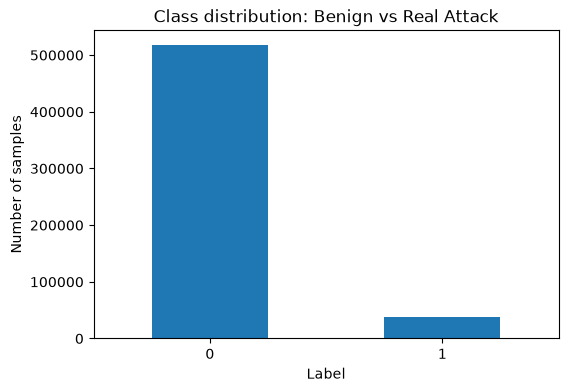

In [7]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Class distribution: Benign vs Real Attack")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()


,count,percentage
traffic_category,,
Benign,347431,62.57
Background,170151,30.64
Probing,23388,4.21
Bruteforce,5884,1.06
Bruteforce-XML,5145,0.93
XMRIGCC CryptoMiner,3279,0.59


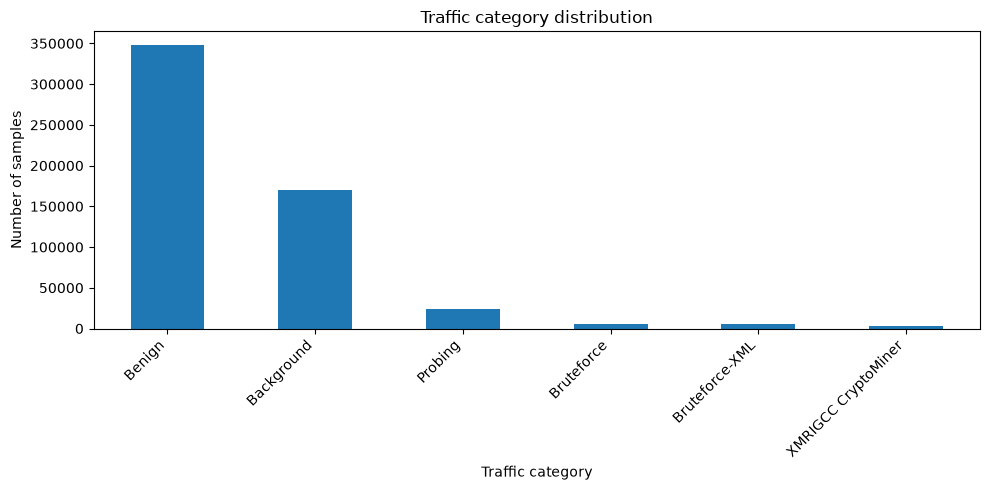

Label,0,1
traffic_category,,
Background,170151,0
Benign,347431,0
Bruteforce,0,5884
Bruteforce-XML,0,5145
Probing,0,23388
XMRIGCC CryptoMiner,0,3279


In [8]:
#traffic_category analysis
if "traffic_category" in df.columns: 
    traffic_summary = pd.DataFrame({
        "count": df["traffic_category"].value_counts(),
        "percentage": (df["traffic_category"].value_counts(normalize=True) * 100).round(2)
    })
    display(traffic_summary) 

    plt.figure(figsize=(10, 5))
    df["traffic_category"].value_counts().plot(kind="bar")
    plt.title("Traffic category distribution")
    plt.xlabel("Traffic category")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(df["traffic_category"], df["Label"]))
else:
    print("Column 'traffic_category' not found. Skipping traffic category analysis.")


## 5. Quick dataset summary

This step creates a compact summary of the dataset.

**Purpose:** this information can be reused later in the written report or presentation. It also acts as a quality gate before moving into preprocessing.

**Why it matters:** when reporting a Machine Learning experiment, the reader must know the dataset size, number of features, missing values, duplicates and number of target classes. Without this, the methodology is incomplete and hard to reproduce.

In [9]:
#summary of the dataset.
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicates": int(df.duplicated().sum()),
    "missing_values_total": int(df.isna().sum().sum()),
    "target_column": "Label",
    "number_of_classes label": int(df["Label"].nunique())
}
#display(df.tail(5))
display(summary)


{'rows': 555278,
 'columns': 88,
 'duplicates': 0,
 'missing_values_total': 0,
 'target_column': 'Label',
 'number_of_classes label': 2}

## 6. Feature preparation

This step defines the model input matrix `X` and the target vector `y`.

**What happens here:**

- `Label` is separated as the target variable.
- Identifier columns are removed.
- Network host fields such as origin/responder identifiers are removed.
- Categorical descriptors such as `traffic_category` are excluded from the numeric baseline model.
- Only numeric features are selected for training.

**Why this matters:** identifiers such as unique IDs, IP-like fields, or dataset-specific indexes can create misleading performance. The model may memorize dataset artifacts instead of learning generalizable traffic behaviour.

**Trade-off:** removing categorical fields simplifies the baseline and reduces leakage risk, but it may also discard useful information. A future improvement could encode selected categorical features using one-hot encoding, but only after verifying that they are legitimate predictors and not leakage fields.

In [10]:
target_col = "Label"

drop_cols = [
    "Unnamed: 0.1",
    "Unnamed: 0",
    "uid",
    "originh",
    "responh",
    "traffic_category",
    "Label"
]

# Removes the specified columns from the DataFrame df to create a new DataFrame X_raw, 
# which will be used as the feature matrix for machine learning. 
# The errors="ignore" parameter ensures that if any of the specified columns are not found in df, 
# no error will be raised, and those columns will simply be ignored.
X_raw = df.drop(columns=drop_cols, errors="ignore")

#Builds the target variable y by selecting the "Label" column from df and converting its data type to integer. 
# This is necessary for machine learning algorithms that require numerical input.
y = df[target_col].astype(int)

# Selects only the numeric columns from X_raw to create a new DataFrame X, 
# which will be used as the feature matrix for machine learning.
X = X_raw.select_dtypes(include=["number"]).copy()

print("Original dataset complete:", df.shape)
print("Original feature matrix shape:", X_raw.shape)
print("Numeric feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of selected numeric features:", X.shape[1])

display(X.head())
display(y.head())

Original dataset complete: (555278, 88)
Original feature matrix shape: (555278, 81)
Numeric feature matrix shape: (555278, 81)
Target shape: (555278,)
Number of selected numeric features: 81


,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,1.000000,432,20,40,480,32,44,2,2,2,6,5,25,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,358.928571,792.173394,0.0,2896.0,6853.0,244.750000,583.468215,16.927719,7.545305e+06,

0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

## 7. Cleaning missing and infinite values

It prepares numeric features so that scikit-learn models can process them.

**Problem:** ML algorithms usually cannot train with `NaN`, `inf`, or `-inf` values. These values can appear in network-flow datasets due to divisions by zero, missing measurements, extraction errors, or abnormal traffic behaviour.

**Solution used here:**

1. Convert infinite values into missing values.
2. Replace missing values with the median value of each feature.

**Why median:** the median is more robust than the mean when features contain extreme outliers, which is common in traffic-flow data.

**Important limitation:** imputation changes the data. In a final paper, this decision should be documented because preprocessing choices directly affect model performance.

In [11]:
# Replace infinite values first because scikit-learn models cannot process them.
X = X.replace([np.inf, -np.inf], np.nan)

# Report missing values before cleaning.
missing_before = int(X.isna().sum().sum())

# Fill missing numeric values with the median of each feature.
# The current dataset contains no missing values, but this keeps the notebook robust.
X = X.fillna(X.median(numeric_only=True))

missing_after = int(X.isna().sum().sum())

print("Missing values before cleaning:", missing_before)
print("Missing values after cleaning:", missing_after)

if missing_after != 0:
    raise ValueError("Missing values remain after cleaning.")

display(X.head())


Missing values before cleaning: 0
Missing values after cleaning: 0


,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,1.000000,432,20,40,480,32,44,2,2,2,6,5,25,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,358.928571,792.173394,0.0,2896.0,6853.0,244.750000,583.468215,16.927719,7.545305e+06,

## 8. Exploratory feature analysis

Checks which numeric features have the strongest linear association with the target label.

**What correlation tells us:** a high absolute correlation means that a feature changes consistently with the label. This can indicate that the feature helps separate benign and malicious flows.

**What correlation does not tell us:** correlation is not causation and does not capture complex non-linear relationships. A feature with low correlation may still be useful for Random Forest or other non-linear models.


In [12]:
numeric_df = pd.concat([X, y.rename("Label")], axis=1) # Create a DataFrame with numeric features and the target variable

# Calculates the absolute correlation of each numeric feature with the target variable "Label" and sorts them in descending order.
correlations = numeric_df.corr(numeric_only=True)["Label"].abs().sort_values(ascending=False) 
display(correlations.head(16))
#display(numeric_df)
#display(X)

Label                    1.000000
bwd_init_window_size     0.321053
bwd_header_size_max      0.291120
fwd_pkts_payload.std     0.283017
bwd_header_size_min      0.281358
fwd_pkts_payload.max     0.265688
bwd_bulk_rate            0.249869
flow_RST_flag_count      0.244015
flow_SYN_flag_count      0.239297
flow_FIN_flag_count      0.231533
fwd_header_size_max      0.220685
fwd_init_window_size     0.214189
fwd_pkts_payload.avg     0.208203
bwd_pkts_payload.std     0.200748
flow_pkts_payload.std    0.194539
flow_pkts_payload.avg    0.182477
Name: Label, dtype: float64

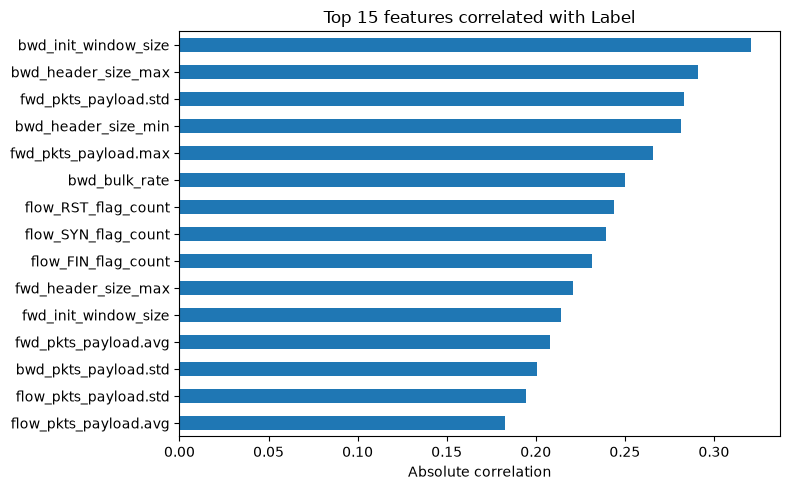

In [13]:
top_corr = correlations.drop("Label", errors="ignore").head(15).sort_values()

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh")
plt.title("Top 15 features correlated with Label")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()


**Why this matters for IDS:** feature analysis supports explainability. Instead of treating the model as a black box, we start identifying which traffic characteristics appear relevant for attack detection.

## 9. Train, validation and test split

This step separates the data into three independent subsets:

- **Training set (64%)** — used to fit the candidate models.
- **Validation set (16%)** — used to compare models and the three Decision Tree configurations.
- **Test set (20%)** — isolated until the final model has been selected.

Stratification preserves the original benign/attack distribution in every subset.

**Why this improves the methodology:** the test set is no longer used to choose the model. It is used only once for the final performance estimate, reducing optimistic bias.


In [14]:
# First split: reserve 20% as the untouched final test set.
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: divide the remaining 80% into training and validation data.
# Final proportions: 64% training, 16% validation and 20% testing.
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Final test features:", X_test.shape)

print("\nTraining class distribution (%):")
display(y_train.value_counts(normalize=True).sort_index().mul(100).rename("training_percentage"))

print("\nValidation class distribution (%):")
display(y_val.value_counts(normalize=True).sort_index().mul(100).rename("validation_percentage"))

print("\nTest class distribution (%):")
display(y_test.value_counts(normalize=True).sort_index().mul(100).rename("test_percentage"))


Training features: (355377, 81)
Validation features: (88845, 81)
Final test features: (111056, 81)

Training class distribution (%):


Label
0    93.211153
1     6.788847
Name: training_percentage, dtype: float64


Validation class distribution (%):


Label
0    93.211773
1     6.788227
Name: validation_percentage, dtype: float64


Test class distribution (%):


Label
0    93.211533
1     6.788467
Name: test_percentage, dtype: float64

## 10. Scaling for Logistic Regression

Logistic Regression is sensitive to feature magnitude, so its input features are standardized.

The scaler is fitted **only on the training set**. The validation and test sets are transformed with the same training-derived parameters.

**Why this matters:** fitting the scaler on validation or test data would leak information from data that should remain unseen.


In [15]:
scaler = StandardScaler()

# Learn the mean and standard deviation only from the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to validation and test data.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (355377, 81)
Scaled validation shape: (88845, 81)
Scaled test shape: (111056, 81)


## 11. Model 1 — Logistic Regression classifier

Logistic Regression is the linear baseline.

The model is fitted on the training set and evaluated on the validation set. The final test set is not used at this stage.


In [16]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=None
)

log_model.fit(X_train_scaled, y_train)

# Validation predictions used for model comparison.
y_pred_log_val = log_model.predict(X_val_scaled)
y_score_log_val = log_model.predict_proba(X_val_scaled)[:, 1]

validation_accuracy = 100.0 * accuracy_score(y_val, y_pred_log_val)
print(f"Logistic Regression validation accuracy: {validation_accuracy:.2f}%")


Logistic Regression validation accuracy: 84.23%


## 12. Model 2 — Random Forest classifier

Random Forest is the ensemble baseline.

The model is fitted on the training set and evaluated on the validation set. The final test set remains isolated.


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Validation predictions used for model comparison.
y_pred_rf_val = rf_model.predict(X_val)
y_score_rf_val = rf_model.predict_proba(X_val)[:, 1]

validation_accuracy = 100.0 * accuracy_score(y_val, y_pred_rf_val)
print(f"Random Forest validation accuracy: {validation_accuracy:.2f}%")


Random Forest validation accuracy: 87.89%


## 13. Model 3 — Decision Tree with limited tuning

Instead of using one arbitrary tree configuration, three simple configurations are compared:

- **Conservative:** shallower tree and larger leaves.
- **Current:** the original notebook configuration.
- **Deeper:** greater model capacity.

This is a lightweight form of hyperparameter tuning that improves the experiment without introducing a complex search procedure.


In [18]:
decision_tree_candidates = {
    "Decision Tree — Conservative": {
        "max_depth": 6,
        "min_samples_leaf": 50
    },
    "Decision Tree — Current": {
        "max_depth": 10,
        "min_samples_leaf": 20
    },
    "Decision Tree — Deeper": {
        "max_depth": 14,
        "min_samples_leaf": 20
    }
}

dt_candidate_models = {}
dt_candidate_outputs = {}

for model_name, parameters in decision_tree_candidates.items():
    model = DecisionTreeClassifier(
        max_depth=parameters["max_depth"],
        min_samples_leaf=parameters["min_samples_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_score = model.predict_proba(X_val)[:, 1]

    dt_candidate_models[model_name] = model
    dt_candidate_outputs[model_name] = {
        "prediction": y_pred,
        "score": y_score
    }

    validation_accuracy = 100.0 * accuracy_score(y_val, y_pred)
    print(f"{model_name} validation accuracy: {validation_accuracy:.2f}%")


Decision Tree — Conservative validation accuracy: 83.91%
Decision Tree — Current validation accuracy: 85.83%
Decision Tree — Deeper validation accuracy: 86.10%


## 14. Evaluation and model-selection methodology

Models are compared on the **validation set**, not on the final test set.

The following metrics are used:

- **Accuracy:** global proportion of correct classifications.
- **Precision:** proportion of attack alerts that are genuinely malicious.
- **Recall:** proportion of attacks that are detected.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ranking performance across classification thresholds.
- **PR-AUC:** precision-recall performance, particularly relevant for imbalanced IDS data.

### Selection rule

1. Keep models with attack recall of at least **98%**.
2. Among them, select the model with the highest **PR-AUC**.
3. If no model reaches the recall target, select the model with the highest PR-AUC.

This prioritizes attack detection while still considering alert quality.


In [19]:
def evaluate_model(model_name, y_true, y_pred, y_score, print_details=True):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

    if print_details:
        print(f"=== {model_name} ===")
        print(classification_report(y_true, y_pred, zero_division=0))
        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

    return results


### Validation comparison and automatic model selection

The table below compares all candidate models using only the validation set.

The selected model is then retrained using the complete development dataset (`training + validation`) before being evaluated once on the untouched test set.


In [20]:
validation_outputs = {
    "Logistic Regression": {
        "prediction": y_pred_log_val,
        "score": y_score_log_val
    },
    "Random Forest": {
        "prediction": y_pred_rf_val,
        "score": y_score_rf_val
    },
    **dt_candidate_outputs
}

validation_results = []

for model_name, output in validation_outputs.items():
    validation_results.append(
        evaluate_model(
            model_name,
            y_val,
            output["prediction"],
            output["score"],
            print_details=False
        )
    )

validation_results_df = pd.DataFrame(validation_results)

# Models that satisfy the minimum attack-recall requirement.
eligible_models = validation_results_df[
    validation_results_df["Recall"] >= MINIMUM_ATTACK_RECALL
].copy()

if eligible_models.empty:
    selection_pool = validation_results_df
    selection_note = (
        "No model reached the minimum recall target. "
        "The model with the highest validation PR-AUC was selected."
    )
else:
    selection_pool = eligible_models
    selection_note = (
        f"Models with recall >= {MINIMUM_ATTACK_RECALL:.0%} were retained. "
        "The model with the highest validation PR-AUC was selected."
    )

selected_row = selection_pool.sort_values(
    by=["PR-AUC", "F1-score", "Precision"],
    ascending=False
).iloc[0]

selected_model_name = selected_row["Model"]

print(selection_note)
print(f"Selected model: {selected_model_name}")

display(
    validation_results_df.sort_values(
        by=["PR-AUC", "Recall", "F1-score"],
        ascending=False
    ).reset_index(drop=True)
)

# Preserve the strongest Decision Tree candidate for feature-importance analysis.
dt_validation_rows = validation_results_df[
    validation_results_df["Model"].str.startswith("Decision Tree")
]

best_dt_name = dt_validation_rows.sort_values(
    by=["PR-AUC", "Recall", "F1-score"],
    ascending=False
).iloc[0]["Model"]

dt_model = dt_candidate_models[best_dt_name]
y_pred_dt_val = dt_candidate_outputs[best_dt_name]["prediction"]
y_score_dt_val = dt_candidate_outputs[best_dt_name]["score"]

print(f"Best Decision Tree configuration: {best_dt_name}")


Models with recall >= 98% were retained. The model with the highest validation PR-AUC was selected.
Selected model: Decision Tree — Deeper


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Decision Tree — Deeper,0.860971,0.327644,0.996186,0.493106,0.946939,0.453628
1,Decision Tree — Current,0.858338,0.323648,0.997347,0.488707,0.944642,0.423766
2,Logistic Regression,0.842332,0.299583,0.988559,0.459818,0.933659,0.372456
3,Decision Tree — Conservative,0.839079,0.296584,0.999171,0.457399,0.929820,0.352982
4,Random Forest,0.878924,0.251525,0.396617,0.307831,0.905273,0.249375


Best Decision Tree configuration: Decision Tree — Deeper


## 15. Retrain the selected model and perform the final test

After model selection, the preferred configuration is retrained using the complete development dataset:

- Training data: 64%
- Validation data: 16%
- Combined development data: 80%

The final test set is used only in this section. This produces a more credible estimate of performance on unseen data.


In [21]:
if selected_model_name == "Logistic Regression":
    final_scaler = StandardScaler()
    X_dev_final = final_scaler.fit_transform(X_dev)
    X_test_final = final_scaler.transform(X_test)

    final_model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=None
    )

    final_model.fit(X_dev_final, y_dev)
    y_pred_final = final_model.predict(X_test_final)
    y_score_final = final_model.predict_proba(X_test_final)[:, 1]

elif selected_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )

    final_model.fit(X_dev, y_dev)
    y_pred_final = final_model.predict(X_test)
    y_score_final = final_model.predict_proba(X_test)[:, 1]

else:
    selected_dt_parameters = decision_tree_candidates[selected_model_name]

    final_model = DecisionTreeClassifier(
        max_depth=selected_dt_parameters["max_depth"],
        min_samples_leaf=selected_dt_parameters["min_samples_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    final_model.fit(X_dev, y_dev)
    y_pred_final = final_model.predict(X_test)
    y_score_final = final_model.predict_proba(X_test)[:, 1]

final_test_results = evaluate_model(
    f"{selected_model_name} — Final Test",
    y_test,
    y_pred_final,
    y_score_final,
    print_details=True
)

final_test_results_df = pd.DataFrame([final_test_results])
display(final_test_results_df)


=== Decision Tree — Deeper — Final Test ===
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    103517
           1       0.33      1.00      0.50      7539

    accuracy                           0.86    111056
   macro avg       0.67      0.92      0.71    111056
weighted avg       0.95      0.86      0.89    111056

Confusion Matrix:
[[88388 15129]
 [   30  7509]]


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Decision Tree — Deeper — Final Test,0.863501,0.331699,0.996021,0.497664,0.947787,0.456104


## 16. Confusion matrices

The validation confusion matrices show the operational trade-off of each candidate model during model selection.

The final selected model's test confusion matrix is also displayed in this section.

- **True Positive (TP):** attack correctly detected.
- **False Positive (FP):** benign flow incorrectly flagged as an attack.
- **False Negative (FN):** attack missed by the IDS.
- **True Negative (TN):** benign flow correctly classified.


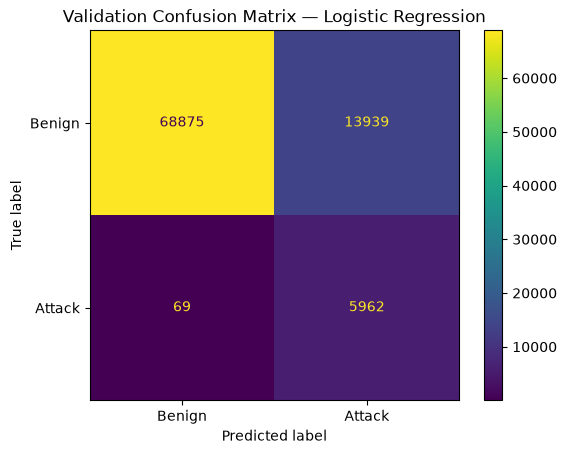

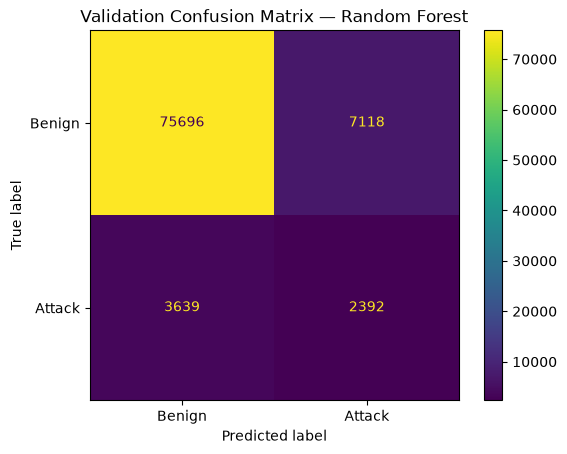

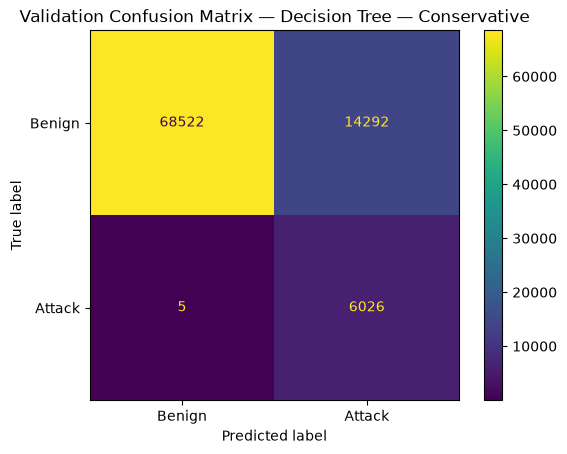

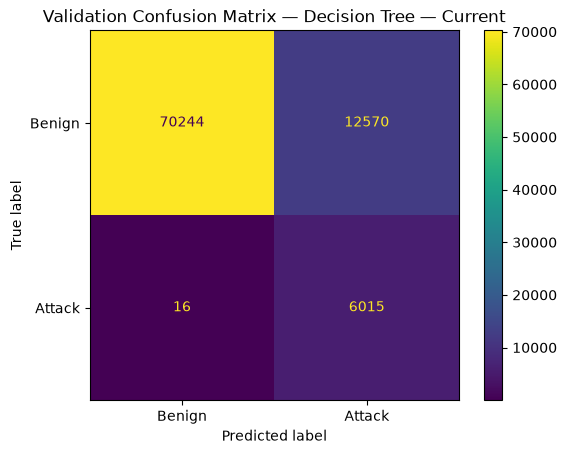

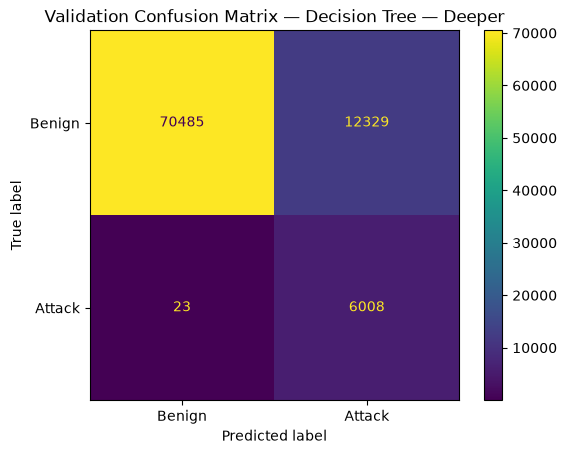

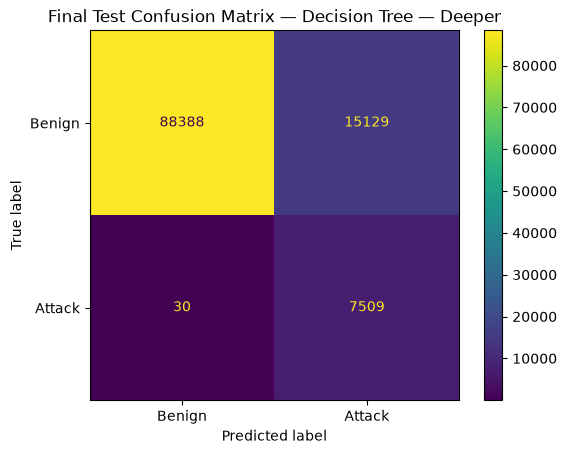

In [22]:
for model_name, output in validation_outputs.items():
    cm = confusion_matrix(y_val, output["prediction"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )
    disp.plot(values_format="d")
    plt.title(f"Validation Confusion Matrix — {model_name}")
    plt.show()

# Final selected model on the untouched test set.
final_cm = confusion_matrix(y_test, y_pred_final)
final_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Benign", "Attack"]
)
final_disp.plot(values_format="d")
plt.title(f"Final Test Confusion Matrix — {selected_model_name}")
plt.show()


## 17. ROC and Precision-Recall curves

The following curves compare all candidate models on the validation set.

- **ROC curve:** compares true-positive rate against false-positive rate.
- **Precision-Recall curve:** focuses on attack detection performance and is more informative for this imbalanced dataset.

All models are placed on the same axes to support direct comparison.


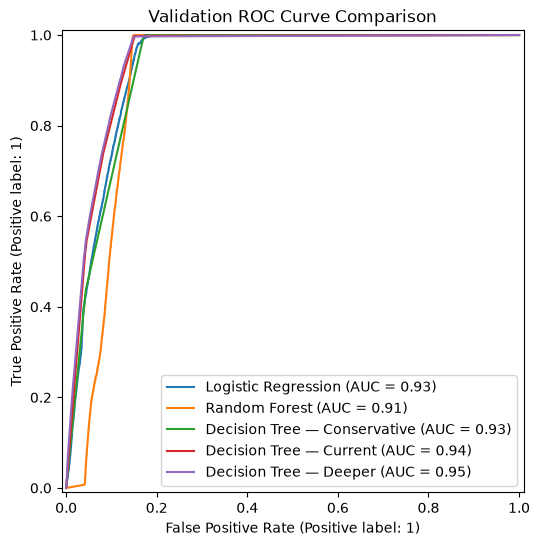

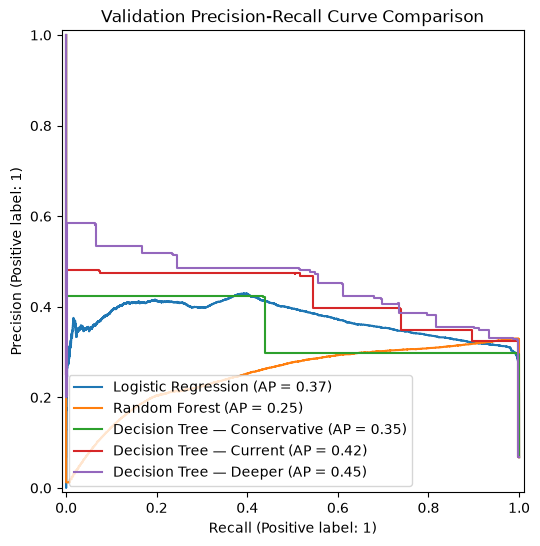

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, output in validation_outputs.items():
    RocCurveDisplay.from_predictions(
        y_val,
        output["score"],
        name=model_name,
        ax=ax
    )

ax.set_title("Validation ROC Curve Comparison")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, output in validation_outputs.items():
    PrecisionRecallDisplay.from_predictions(
        y_val,
        output["score"],
        name=model_name,
        ax=ax
    )

ax.set_title("Validation Precision-Recall Curve Comparison")
plt.show()


## 18. Best Decision Tree feature importance

This section identifies the most influential features in the strongest Decision Tree configuration found during validation.

Feature importance supports explainability, but it does not prove that a feature is causally related to malicious activity. A dominant feature may also indicate dataset-specific behaviour.


In [24]:
dt_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

dt_feature_importance.head(15)

,Feature,Importance
5,fwd_data_pkts_tot,0.705275
79,bwd_init_window_size,0.148159
47,bwd_iat.min,0.041083
54,flow_iat.tot,0.031346
17,flow_FIN_flag_count,0.021525
28,fwd_pkts_payload.max,0.009574
80,fwd_last_window_size,0.007556
2,flow_duration,0.006678
68,active.min,0.003241
10,down_up_ratio,0.003121


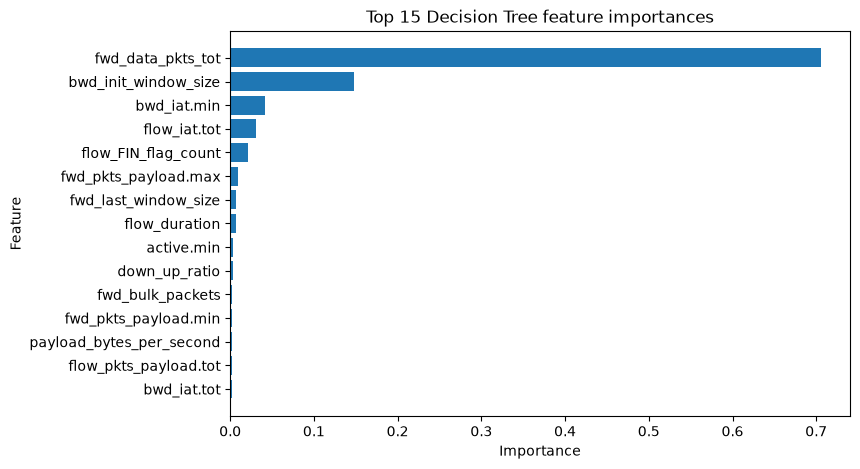

In [25]:
dt_top_features = dt_feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(dt_top_features["Feature"], dt_top_features["Importance"])
plt.title("Top 15 Decision Tree feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 19. Random Forest feature importance

This step identifies which features contributed most to the Random Forest validation model.

Random Forest importance is included for comparison with the Decision Tree. These impurity-based values should be interpreted carefully because correlated features can divide importance between them.


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))


,Feature,Importance
60,fwd_subflow_bytes,0.068989
46,fwd_iat.std,0.057804
5,fwd_data_pkts_tot,0.053410
79,bwd_init_window_size,0.051838
43,fwd_iat.max,0.050987
70,active.tot,0.049439
3,fwd_pkts_tot,0.045421
44,fwd_iat.tot,0.031308
29,fwd_pkts_payload.tot,0.029896
2,flow_duration,0.029814


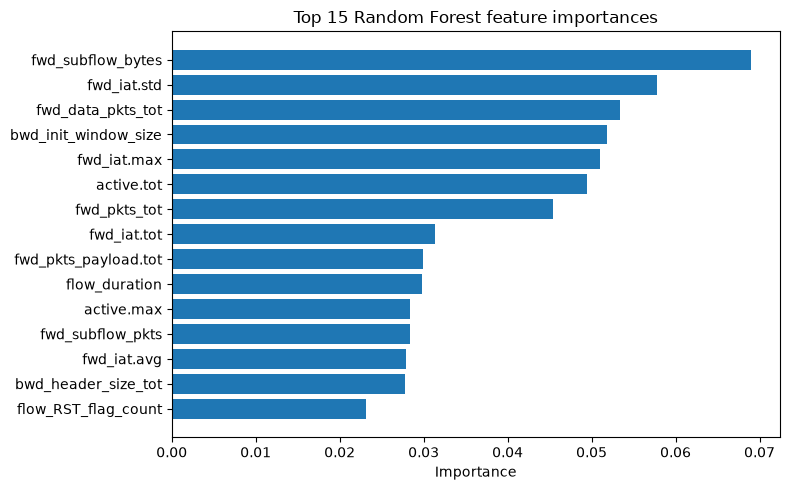

In [27]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 20. Cybersecurity interpretation of results

Model selection must not be based only on accuracy. In an IDS, the impact of each error type is different:

- **False negatives** are attacks that remain undetected. They may enable compromise, persistence, lateral movement or data leakage.
- **False positives** are benign flows classified as attacks. They increase alert volume and analyst workload.

The validation strategy therefore applies a minimum attack-recall target of 98% and then uses PR-AUC to select among the eligible models.

This creates a security-oriented decision rule:

- Recall controls the risk of missed attacks.
- Precision measures the quality of generated alerts.
- PR-AUC evaluates ranking performance under class imbalance.
- The final test result estimates how the selected model generalizes to data that did not influence model selection.


## 21. Results discussion

The validation table is the evidence used to compare Logistic Regression, Random Forest and the three Decision Tree configurations.

The selected model is not simply the model with the highest accuracy. It must first satisfy the minimum attack-recall requirement whenever possible. Among the eligible candidates, the model with the highest validation PR-AUC is selected.

After selection, the preferred configuration is retrained on the full development set and evaluated once on the untouched test set.

When interpreting the final result, verify:

- Whether test recall remains close to validation recall.
- Whether the number of false negatives is operationally acceptable.
- Whether precision is sufficient to avoid excessive alert fatigue.
- Whether PR-AUC remains stable between validation and test data.

A substantial performance drop from validation to test would indicate that the model does not generalize reliably.


## 22. Limitations

This experiment has been improved with separate training, validation and test subsets, but important limitations remain:

1. The evaluation still uses one fixed split rather than repeated cross-validation.
2. The tuning process tests only three Decision Tree configurations and is not an exhaustive search.
3. The dataset is evaluated with a random row-level split. Similar flows from the same capture or host may appear in different subsets.
4. The models are evaluated offline rather than in a real-time IDS deployment.
5. The dataset may not represent current production network behaviour.
6. Only Logistic Regression, Decision Tree and Random Forest are evaluated.
7. No independent external IDS dataset is used for validation.
8. No adversarial robustness testing is performed.
9. Explainability is limited to tree-based feature importance.

These limitations distinguish a controlled academic experiment from a production-grade IDS.


## 23. Conclusion

This notebook implements a supervised Machine Learning pipeline for intrusion detection using the ALLFLOWMETER_HIKARI2021 dataset.

The improved workflow includes:

- Dataset loading, inspection and cleaning.
- Exploratory feature analysis.
- A stratified 64% training, 16% validation and 20% test split.
- Logistic Regression and Random Forest baselines.
- Limited tuning of three Decision Tree configurations.
- Model selection based on attack recall and validation PR-AUC.
- Retraining of the selected model on the complete development set.
- One final evaluation on the untouched test set.
- Confusion matrices, ROC curves, Precision-Recall curves and feature importance.

**Main takeaway:** accuracy alone is not sufficient for intrusion detection. The selected model must detect attacks consistently while keeping false positives operationally manageable.

Separating validation from final testing materially improves the credibility of the results because the test set no longer influences model selection.


## References

- HIKARI2021 / ALLFLOWMETER_HIKARI2021 dataset documentation.
- Scikit-learn documentation: supervised learning, Logistic Regression, Random Forest and model evaluation metrics.
- Rui Fernandes, *AI for Cybersecurity* course materials.
- Rui Fernandes, *Scientific Writing - Introduction* course materials.

